#                                  Multi Class Clasification - 2D

# Load Data

In [18]:
import pandas as pd
import os

In [49]:

file_name = "diabetes_dataset"
root_folder = f'multi-class-clasification/two-d/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

#buang kolom tidak dibutuhkan
df.drop(columns=['diagnosed_diabetes'], inplace=True)

print("Sebulum DROP nan : " + str(df.shape) )
df = df.dropna() #Drop Nan
print("Setelah DROP nan : " + str(df.shape) )

#gabungkan data karena data kurang banyak
# gestational -> Type 2
df["diabetes_stage"] = df["diabetes_stage"].str.replace(
    r"(?i)gestational", "Type 2", regex=True
)
# Tipe 1 -> Type 2
df["diabetes_stage"] = df["diabetes_stage"].str.replace(
    r"(?i)Type 1", "Type 2", regex=True
)

Sebulum DROP nan : (100000, 30)
Setelah DROP nan : (100000, 30)


In [50]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,239,41,160,145,136,236,6.36,8.18,29.6,Type 2
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,213,66,99,36,118,195,5.07,7.51,44.7,Type 2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,171,50,79,140,139,253,5.28,9.03,38.2,Type 2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,210,52,125,160,137,184,12.74,7.20,23.5,Type 2


#### LabelEncoder

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_gender']            = le.fit_transform(df['gender'])
df['label_ethnicity']         = le.fit_transform(df['ethnicity'])
df['label_income_level']      = le.fit_transform(df['income_level'])
df['label_education_level']   = le.fit_transform(df['education_level'])
df['label_employment_status'] = le.fit_transform(df['employment_status'])
df['label_smoking_status']    = le.fit_transform(df['smoking_status'])

#label target
# Konversi ke kategori otomatis
df["diabetes_stage"] = df["diabetes_stage"].astype("category")

# Buat kolom label otomatis (0,1,2,3,...)
df["label_diabetes_stage"] = df["diabetes_stage"].cat.codes

labels = dict(enumerate(df["diabetes_stage"].cat.categories))
print(labels)


{0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Type 2'}


In [53]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hba1c,diabetes_risk_score,diabetes_stage,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,label_diabetes_stage
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,8.18,29.6,Type 2,1,0,2,1,0,2,2
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,5.63,23.0,No Diabetes,0,4,3,1,0,1,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,7.51,44.7,Type 2,1,2,3,1,3,2,2
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,9.03,38.2,Type 2,0,1,1,1,1,2,2
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,7.20,23.5,Type 2,1,4,3,0,1,2,2


#### Scaler

In [54]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_gender', 
    'label_ethnicity', 
    'label_income_level',
    'label_education_level',
    'label_employment_status', 
    'label_smoking_status',
    #--------------------------
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'glucose_postprandial',
    'insulin_level',
    'hba1c',
    'diabetes_risk_score'
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_gender' saved as scaler_label_gender.pkl
✅ Scaler for 'label_ethnicity' saved as scaler_label_ethnicity.pkl
✅ Scaler for 'label_income_level' saved as scaler_label_income_level.pkl
✅ Scaler for 'label_education_level' saved as scaler_label_education_level.pkl
✅ Scaler for 'label_employment_status' saved as scaler_label_employment_status.pkl
✅ Scaler for 'label_smoking_status' saved as scaler_label_smoking_status.pkl
✅ Scaler for 'age' saved as scaler_age.pkl
✅ Scaler for 'physical_activity_minutes_per_week' saved as scaler_physical_activity_minutes_per_week.pkl
✅ Scaler for 'diet_score' saved as scaler_diet_score.pkl
✅ Scaler for 'sleep_hours_per_day' saved as scaler_sleep_hours_per_day.pkl
✅ Scaler for 'glucose_postprandial' saved as scaler_glucose_postprandial.pkl
✅ Scaler for 'insulin_level' saved as scaler_insulin_level.pkl
✅ Scaler for 'hba1c' saved as scaler_hba1c.pkl
✅ Scaler for 'diabetes_risk_score' saved as scaler_diabetes_risk_score.pkl

All individual sc

In [55]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hba1c,diabetes_risk_score,diabetes_stage,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,label_diabetes_stage
0,0.555556,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,0.258103,0.57,...,0.720690,0.417054,Type 2,0.5,0.00,0.50,0.333333,0.000000,1.0,2
1,0.416667,Female,White,Highschool,Middle,Employed,Former,1,0.171669,0.67,...,0.281034,0.314729,No Diabetes,0.0,1.00,0.75,0.333333,0.000000,0.5,0
2,0.583333,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,0.068427,0.64,...,0.605172,0.651163,Type 2,0.5,0.50,0.75,0.333333,1.000000,1.0,2
3,0.777778,Female,Black,Highschool,Low,Retired,Never,0,0.058824,0.34,...,0.867241,0.550388,Type 2,0.0,0.25,0.25,0.333333,0.333333,1.0,2
4,0.388889,Male,White,Graduate,Middle,Retired,Never,1,0.130852,0.72,...,0.551724,0.322481,Type 2,0.5,1.00,0.75,0.000000,0.333333,1.0,2


#### Mapping label

In [56]:
import json
mapping_dicts = {}

cols = [
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status'
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
mapping_table

,feature,original_value,label_value
0,gender,Male,0.500000
1,gender,Female,0.000000
2,gender,Other,1.000000
3,ethnicity,Asian,0.000000
4,ethnicity,White,1.000000
5,ethnicity,Hispanic,0.500000
6,ethnicity,Black,0.250000
7,ethnicity,Other,0.750000
8,education_level,Highschool,0.333333
9,education_level,Graduate,0.000000


#### Select Kolom To Trian

In [57]:
col_target = 'label_diabetes_stage'
cols = [
    'label_gender', 
    'label_ethnicity', 
    'label_income_level',
    'label_education_level',
    'label_employment_status', 
    'label_smoking_status',
    #--------------------------
    'age',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'glucose_postprandial',
    'insulin_level',
    'hba1c',
    'diabetes_risk_score',
    #------------------------
    col_target
]
df = df[cols].copy()

In [58]:
df.head()

,label_gender,label_ethnicity,label_income_level,label_education_level,label_employment_status,label_smoking_status,age,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,label_diabetes_stage
0,0.5,0.00,0.50,0.333333,0.000000,1.0,0.555556,0.258103,0.57,0.700000,0.764977,0.144275,0.720690,0.417054,2
1,0.0,1.00,0.75,0.333333,0.000000,0.5,0.416667,0.171669,0.67,0.500000,0.368664,0.000000,0.281034,0.314729,0
2,0.5,0.50,0.75,0.333333,1.000000,1.0,0.583333,0.068427,0.64,1.000000,0.576037,0.101588,0.605172,0.651163,2
3,0.0,0.25,0.25,0.333333,0.333333,1.0,0.777778,0.058824,0.34,0.514286,0.843318,0.108537,0.867241,0.550388,2
4,0.5,1.00,0.75,0.000000,0.333333,1.0,0.388889,0.130852,0.72,0.628571,0.525346,0.355394,0.551724,0.322481,2


#### cek keseimbangan data

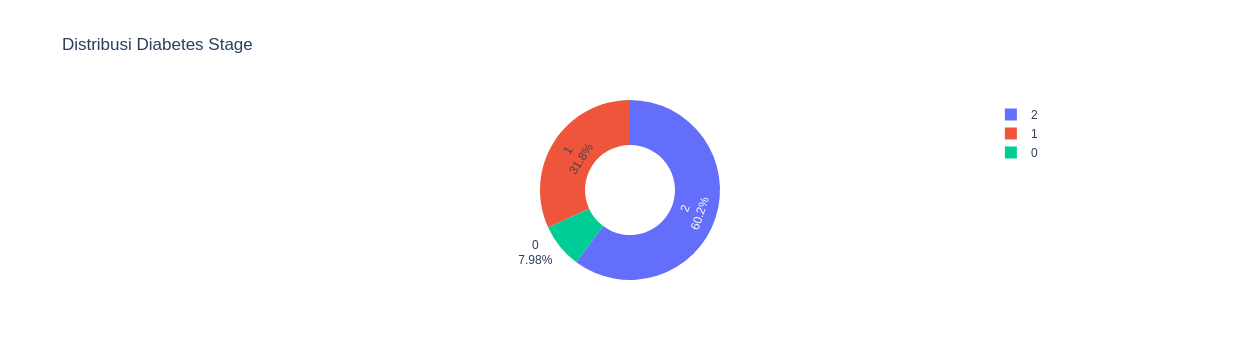

In [59]:
import plotly.express as px

fig = px.pie(
    df,
    names=col_target,
    hole=0.5,  # membuatnya jadi donat
    title='Distribusi Diabetes Stage',
)
fig.update_traces(textinfo='percent+label')
fig.show()

# Data Load To Train

#### select Future to traian

In [80]:
feature_1_cols = [
    'label_gender',
    'age',
    'hba1c',
    #'physical_activity_minutes_per_week',
    #'diet_score',
    #'sleep_hours_per_day',
]
feature_2_cols = [
    'physical_activity_minutes_per_week',
    'glucose_postprandial',
    'insulin_level',
]

target_cols  = col_target

#### Split data

In [81]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# Pisahkan train-test (stratify opsional jika masih punya kolom 'diabetes_stage')
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)


#### DataLoader

In [82]:
from data_set import MultiClass2DDataset

# Buat dataset dengan class kamu
train_dataset = MultiClass2DDataset(X_train, feature_1_cols,feature_2_cols, target_cols, normalize=False)
test_dataset  = MultiClass2DDataset(X_test,  feature_1_cols,feature_2_cols, target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Cek contoh batch
for X1,X2, y in train_loader:
    print("X1 shape:", X1.shape)
    print("X2 shape:", X2.shape)
    print("y  shape:", y.shape)
    print(X1[:3])  # contoh fitur
    print(X2[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X1 shape: torch.Size([32, 3])
X2 shape: torch.Size([32, 3])
y  shape: torch.Size([32])
tensor([[0.5000, 0.3611, 0.4310],
        [0.0000, 0.6528, 0.4293],
        [0.0000, 0.4583, 0.2897]])
tensor([[0.0684, 0.3963, 0.5205],
        [0.2017, 0.3871, 0.0768],
        [0.1729, 0.3364, 0.0675]])
tensor([2, 1, 1])


# Config

In [84]:
from jcopdl.callback import Callback, set_config

config = set_config({
    "labels"         : labels,
    "feature_1_cols" : feature_1_cols,
    "feature_2_cols" : feature_2_cols,
    "input_1_dim"    : len(test_dataset.X1[0]),
    "input_2_dim"    : len(test_dataset.X2[0]),
    "hidden_1_dims"  : [ 16],
    "hidden_2_dims"  : [ 16],
    "combine_dims"   : [16],
    "output_dim"     : len(labels),
    "dropout"        : 0.1,
    "activation"     : "relu",
    "early_stop_patience" : 5,
    "col_target"     : col_target,
})
config

Config(activation=relu, col_target=label_diabetes_stage, combine_dims=[16], dropout=0.1, early_stop_patience=5, feature_1_cols=['label_gender', 'age', 'hba1c'], feature_2_cols=['physical_activity_minutes_per_week', 'glucose_postprandial', 'insulin_level'], hidden_1_dims=[16], hidden_2_dims=[16], input_1_dim=3, input_2_dim=3, labels={0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Type 2'}, output_dim=3)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [85]:
from class_lib import Model2DPure
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model
model = Model2DPure(
    input_dim_1  = config.input_1_dim, 
    input_dim_2  = config.input_2_dim, 
    hidden_dims_1= config.hidden_1_dims,
    hidden_dims_2= config.hidden_2_dims,
    combined_dims= config.combine_dims,
    output_dim   = config.output_dim,
    dropout=config.dropout, 
    activation=config.activation
).to(device)

#Criterion
criterion = nn.CrossEntropyLoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_adam  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

#### Visualisasi Model

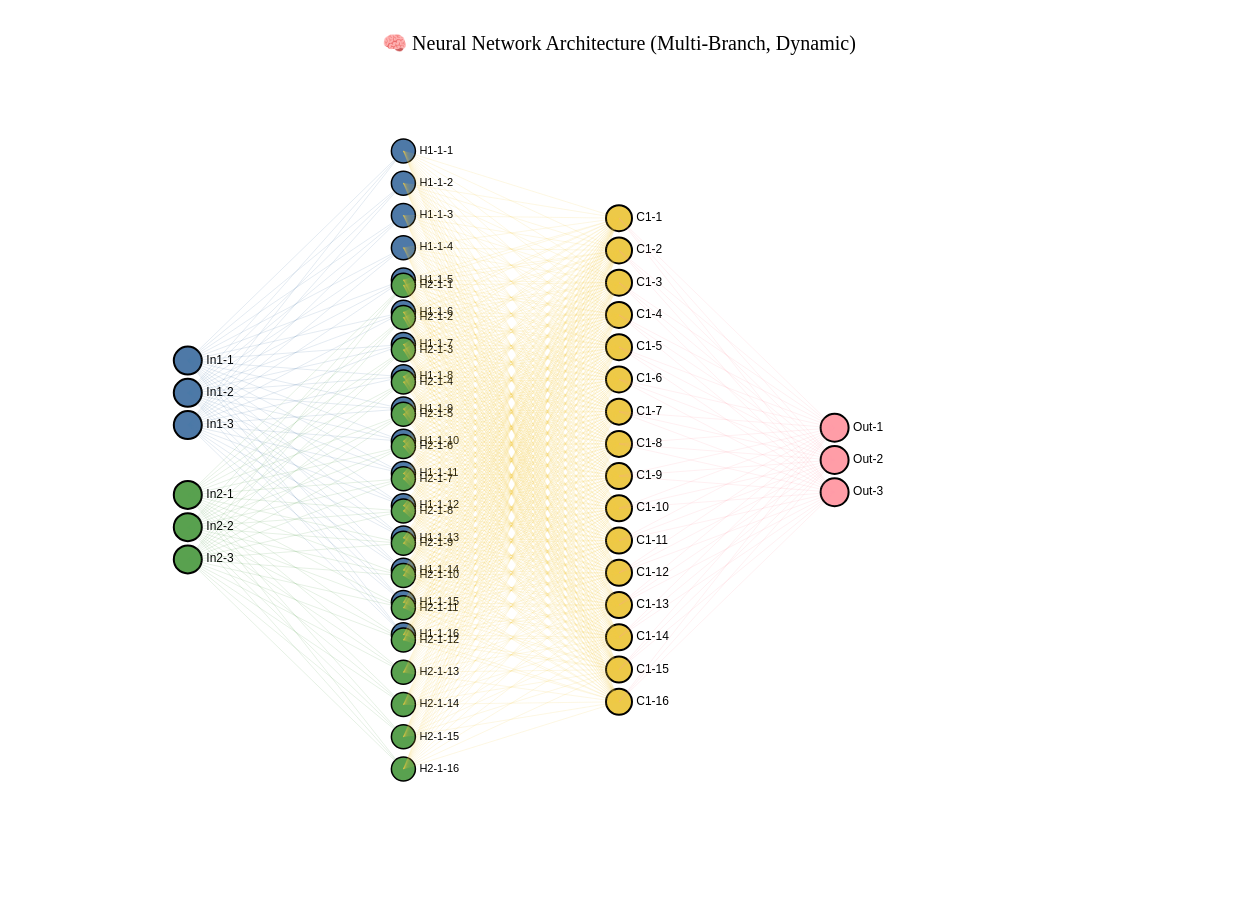

In [86]:
from visualization import plot_dynamic_multi_input_network
plot_dynamic_multi_input_network(
    input_dims=[config.input_1_dim, config.input_2_dim],
    hidden_dims_per_branch=[
        config.hidden_1_dims,
        config.hidden_2_dims
    ],
    combined_dims=config.combine_dims,
    output_dim=config.output_dim,
    figsize=(1000, 900)
)


# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1496.95it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.5307 │ 0.3939 │ │ No Diabetes  │  0.5971  │
│ Accuracy │ 0.7539 │ 0.8194 │ │ Pre-Diabetes │  0.7801  │
│ Macro F1 │ 0.6240 │ 0.7482 │ │    Type 2    │  0.8696  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

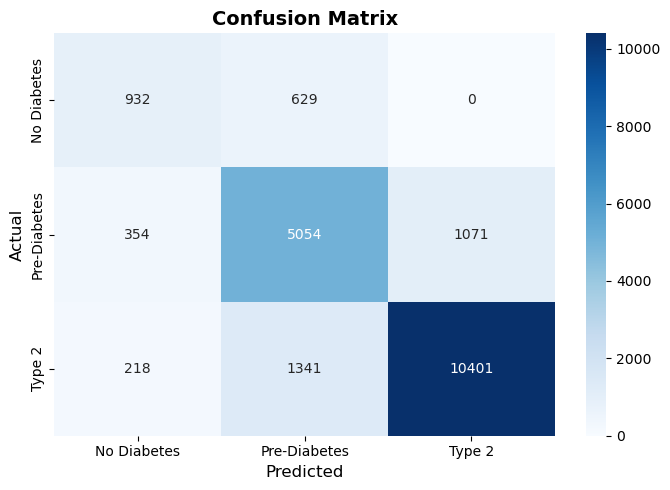


Epoch     1
Train_cost  = 0.5307 | Test_cost  = 0.3939 | Train_score = 0.7539 | Test_score = 0.8194 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1563.54it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3917 │ 0.3548 │ │ No Diabetes  │  0.7687  │
│ Accuracy │ 0.8280 │ 0.8518 │ │ Pre-Diabetes │  0.8767  │
│ Macro F1 │ 0.7577 │ 0.7917 │ │    Type 2    │  0.8492  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

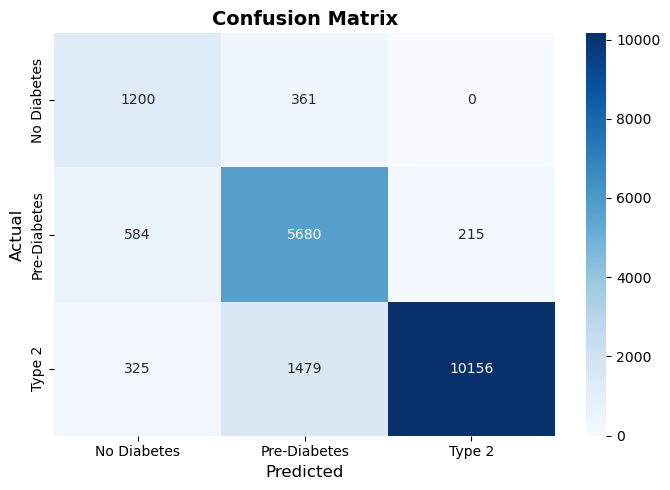


Epoch     2
Train_cost  = 0.3917 | Test_cost  = 0.3548 | Train_score = 0.8280 | Test_score = 0.8518 |


─────────────────────────────────────────────────── 🚀 EPOCH 3 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1443.84it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3625 │ 0.3369 │ │ No Diabetes  │  0.7880  │
│ Accuracy │ 0.8406 │ 0.8537 │ │ Pre-Diabetes │  0.8742  │
│ Macro F1 │ 0.7760 │ 0.7949 │ │    Type 2    │  0.8511  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

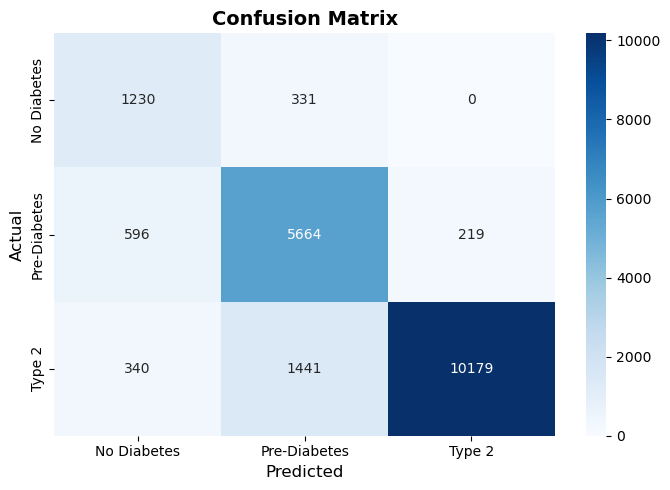


Epoch     3
Train_cost  = 0.3625 | Test_cost  = 0.3369 | Train_score = 0.8406 | Test_score = 0.8537 |


─────────────────────────────────────────────────── 🚀 EPOCH 4 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1543.53it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3480 │ 0.3337 │ │ No Diabetes  │  0.7546  │
│ Accuracy │ 0.8475 │ 0.8542 │ │ Pre-Diabetes │  0.8836  │
│ Macro F1 │ 0.7863 │ 0.7935 │ │    Type 2    │  0.8513  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

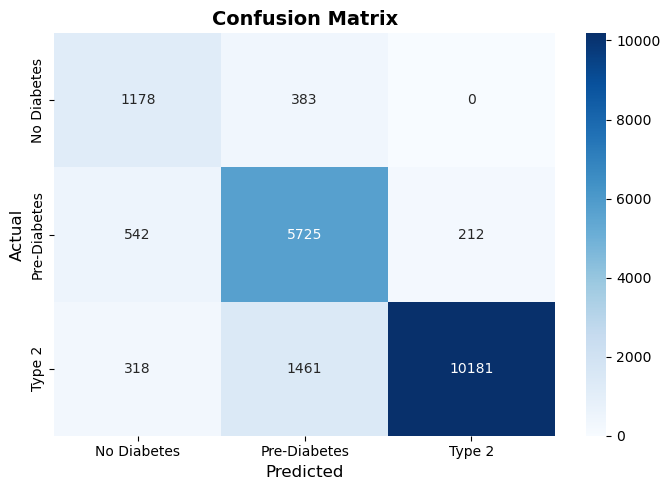


Epoch     4
Train_cost  = 0.3480 | Test_cost  = 0.3337 | Train_score = 0.8475 | Test_score = 0.8542 |


─────────────────────────────────────────────────── 🚀 EPOCH 5 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1533.82it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3410 │ 0.3266 │ │ No Diabetes  │  0.8322  │
│ Accuracy │ 0.8508 │ 0.8570 │ │ Pre-Diabetes │  0.8751  │
│ Macro F1 │ 0.7915 │ 0.8020 │ │    Type 2    │  0.8504  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

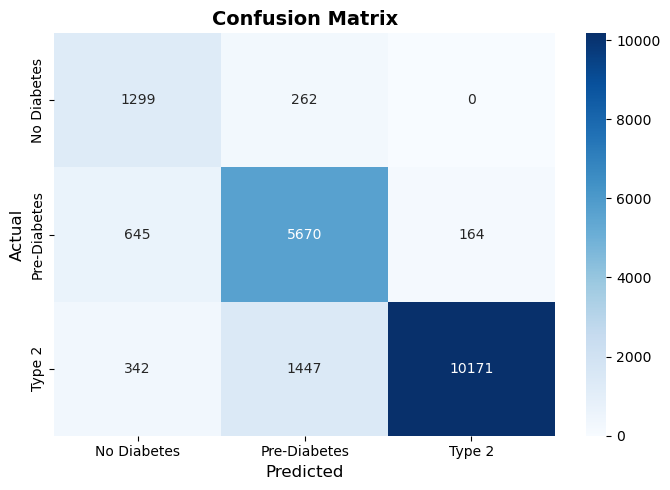


Epoch     5
Train_cost  = 0.3410 | Test_cost  = 0.3266 | Train_score = 0.8508 | Test_score = 0.8570 |


─────────────────────────────────────────────────── 🚀 EPOCH 6 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1422.43it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3353 │ 0.3294 │ │ No Diabetes  │  0.8053  │
│ Accuracy │ 0.8538 │ 0.8524 │ │ Pre-Diabetes │  0.8629  │
│ Macro F1 │ 0.7950 │ 0.7951 │ │    Type 2    │  0.8528  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

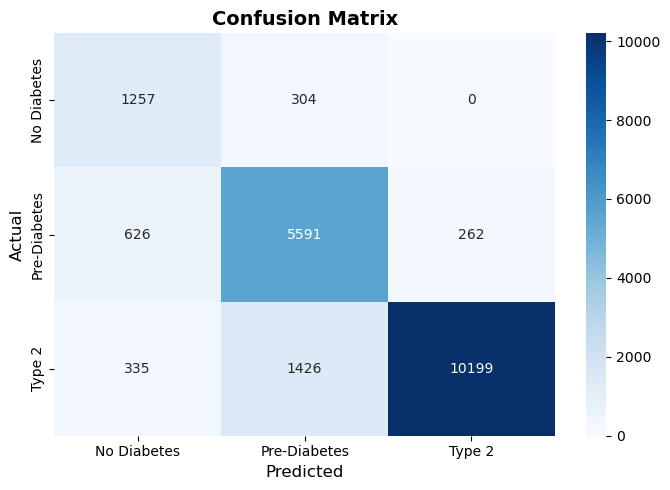


Epoch     6
Train_cost  = 0.3353 | Test_cost  = 0.3294 | Train_score = 0.8538 | Test_score = 0.8524 |
==> EarlyStop patience =  1 | Best test_score: 0.8570


─────────────────────────────────────────────────── 🚀 EPOCH 7 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1522.78it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3331 │ 0.3244 │ │ No Diabetes  │  0.7553  │
│ Accuracy │ 0.8549 │ 0.8600 │ │ Pre-Diabetes │  0.9042  │
│ Macro F1 │ 0.7966 │ 0.8026 │ │    Type 2    │  0.8497  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

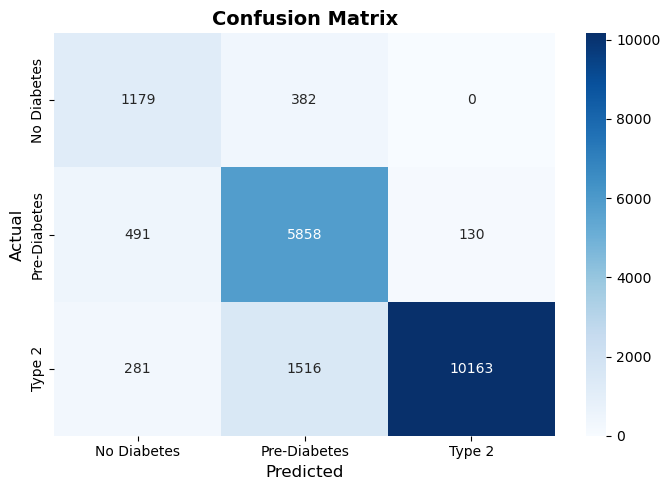


Epoch     7
Train_cost  = 0.3331 | Test_cost  = 0.3244 | Train_score = 0.8549 | Test_score = 0.8600 |


─────────────────────────────────────────────────── 🚀 EPOCH 8 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1549.60it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3306 │ 0.3236 │ │ No Diabetes  │  0.8693  │
│ Accuracy │ 0.8557 │ 0.8598 │ │ Pre-Diabetes │  0.8791  │
│ Macro F1 │ 0.7970 │ 0.8049 │ │    Type 2    │  0.8480  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

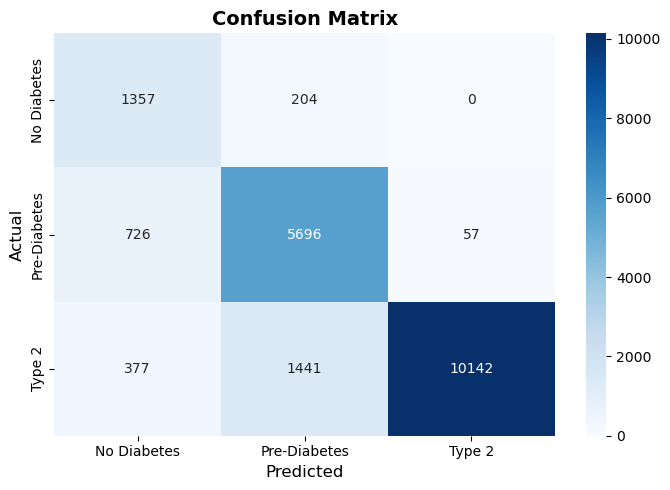


Epoch     8
Train_cost  = 0.3306 | Test_cost  = 0.3236 | Train_score = 0.8557 | Test_score = 0.8598 |
==> EarlyStop patience =  1 | Best test_score: 0.8600


─────────────────────────────────────────────────── 🚀 EPOCH 9 ────────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1510.24it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3294 │ 0.3261 │ │ No Diabetes  │  0.8027  │
│ Accuracy │ 0.8565 │ 0.8600 │ │ Pre-Diabetes │  0.8927  │
│ Macro F1 │ 0.7980 │ 0.8041 │ │    Type 2    │  0.8497  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

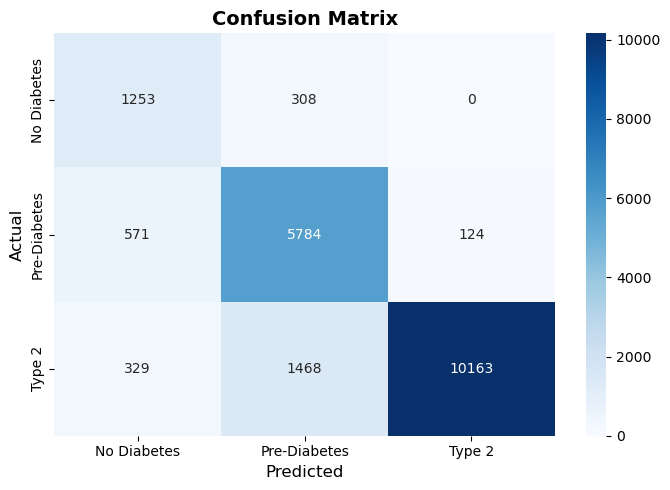


Epoch     9
Train_cost  = 0.3294 | Test_cost  = 0.3261 | Train_score = 0.8565 | Test_score = 0.8600 |
==> EarlyStop patience =  2 | Best test_score: 0.8600


─────────────────────────────────────────────────── 🚀 EPOCH 10 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1524.15it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3277 │ 0.3231 │ │ No Diabetes  │  0.7739  │
│ Accuracy │ 0.8580 │ 0.8611 │ │ Pre-Diabetes │  0.9054  │
│ Macro F1 │ 0.8009 │ 0.8040 │ │    Type 2    │  0.8485  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

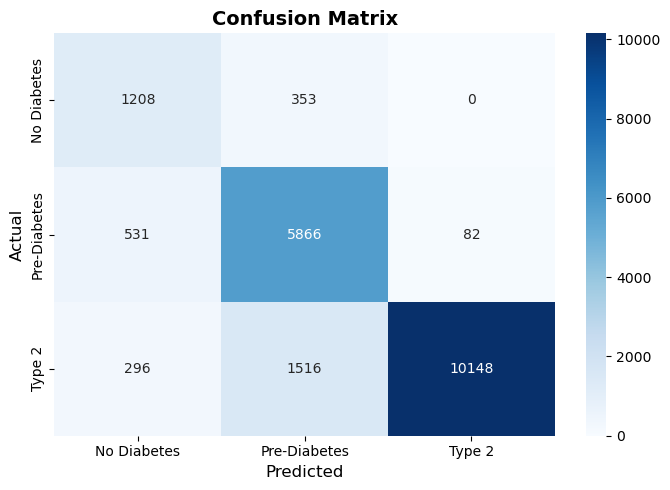


Epoch    10
Train_cost  = 0.3277 | Test_cost  = 0.3231 | Train_score = 0.8580 | Test_score = 0.8611 |


─────────────────────────────────────────────────── 🚀 EPOCH 11 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1543.69it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3271 │ 0.3198 │ │ No Diabetes  │  0.7969  │
│ Accuracy │ 0.8582 │ 0.8618 │ │ Pre-Diabetes │  0.9023  │
│ Macro F1 │ 0.8001 │ 0.8059 │ │    Type 2    │  0.8483  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

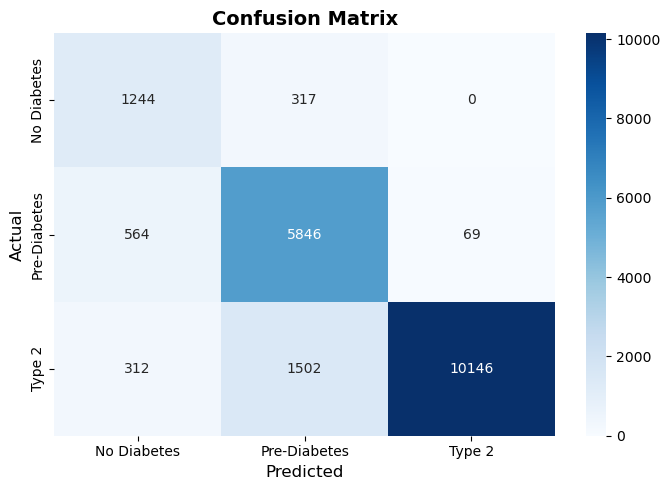


Epoch    11
Train_cost  = 0.3271 | Test_cost  = 0.3198 | Train_score = 0.8582 | Test_score = 0.8618 |


─────────────────────────────────────────────────── 🚀 EPOCH 12 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1505.85it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3267 │ 0.3222 │ │ No Diabetes  │  0.8668  │
│ Accuracy │ 0.8578 │ 0.8603 │ │ Pre-Diabetes │  0.8915  │
│ Macro F1 │ 0.8002 │ 0.8065 │ │    Type 2    │  0.8426  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

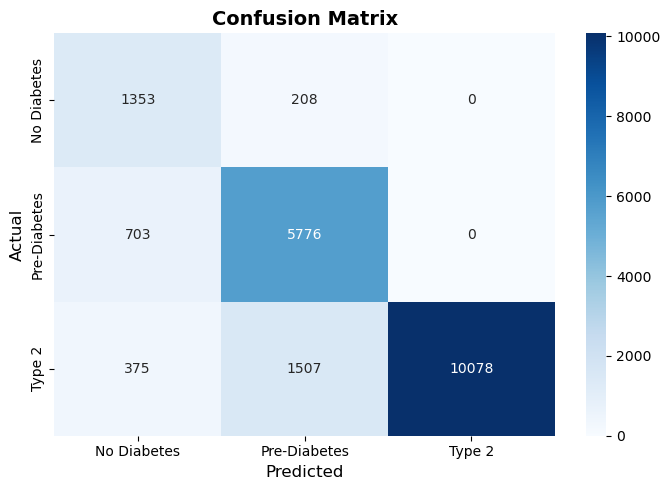


Epoch    12
Train_cost  = 0.3267 | Test_cost  = 0.3222 | Train_score = 0.8578 | Test_score = 0.8603 |
==> EarlyStop patience =  1 | Best test_score: 0.8618


─────────────────────────────────────────────────── 🚀 EPOCH 13 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1530.67it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3268 │ 0.3399 │ │ No Diabetes  │  0.7072  │
│ Accuracy │ 0.8569 │ 0.8543 │ │ Pre-Diabetes │  0.8926  │
│ Macro F1 │ 0.7984 │ 0.7939 │ │    Type 2    │  0.8528  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

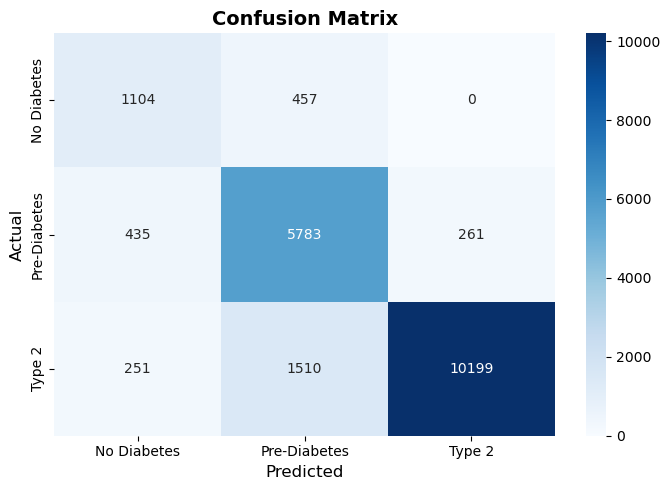


Epoch    13
Train_cost  = 0.3268 | Test_cost  = 0.3399 | Train_score = 0.8569 | Test_score = 0.8543 |
==> EarlyStop patience =  2 | Best test_score: 0.8618


─────────────────────────────────────────────────── 🚀 EPOCH 14 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1521.55it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3260 │ 0.3201 │ │ No Diabetes  │  0.8629  │
│ Accuracy │ 0.8578 │ 0.8594 │ │ Pre-Diabetes │  0.8775  │
│ Macro F1 │ 0.7997 │ 0.8054 │ │    Type 2    │  0.8492  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

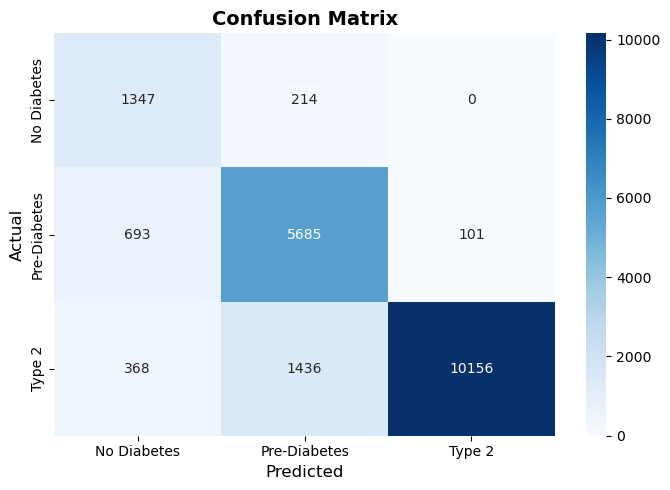


Epoch    14
Train_cost  = 0.3260 | Test_cost  = 0.3201 | Train_score = 0.8578 | Test_score = 0.8594 |
==> EarlyStop patience =  3 | Best test_score: 0.8618


─────────────────────────────────────────────────── 🚀 EPOCH 15 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1504.92it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3254 │ 0.3216 │ │ No Diabetes  │  0.7732  │
│ Accuracy │ 0.8588 │ 0.8594 │ │ Pre-Diabetes │  0.8977  │
│ Macro F1 │ 0.8016 │ 0.8032 │ │    Type 2    │  0.8499  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

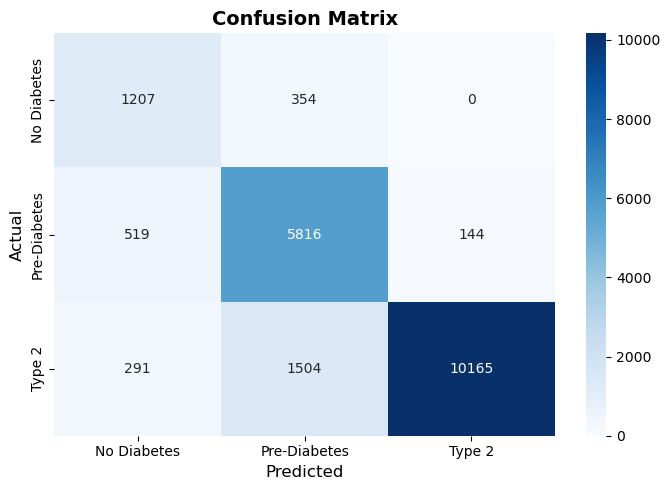


Epoch    15
Train_cost  = 0.3254 | Test_cost  = 0.3216 | Train_score = 0.8588 | Test_score = 0.8594 |
==> EarlyStop patience =  4 | Best test_score: 0.8618


─────────────────────────────────────────────────── 🚀 EPOCH 16 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1430.72it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3253 │ 0.3203 │ │ No Diabetes  │  0.8251  │
│ Accuracy │ 0.8594 │ 0.8629 │ │ Pre-Diabetes │  0.9035  │
│ Macro F1 │ 0.8029 │ 0.8077 │ │    Type 2    │  0.8459  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

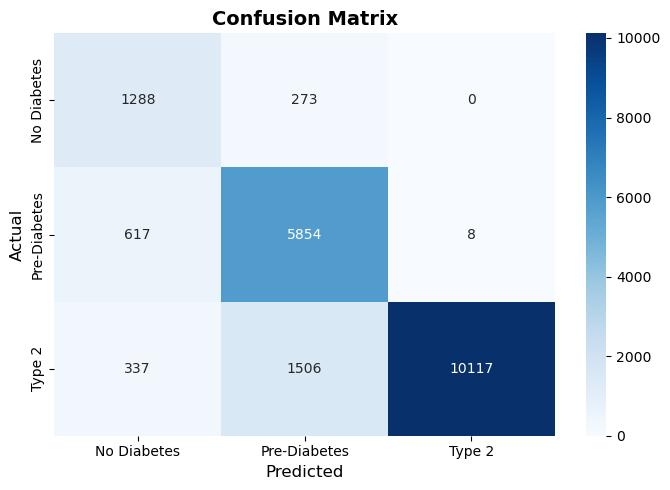


Epoch    16
Train_cost  = 0.3253 | Test_cost  = 0.3203 | Train_score = 0.8594 | Test_score = 0.8629 |


─────────────────────────────────────────────────── 🚀 EPOCH 17 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1422.36it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3254 │ 0.3406 │ │ No Diabetes  │  0.7265  │
│ Accuracy │ 0.8585 │ 0.8495 │ │ Pre-Diabetes │  0.9304  │
│ Macro F1 │ 0.8017 │ 0.7943 │ │    Type 2    │  0.8217  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

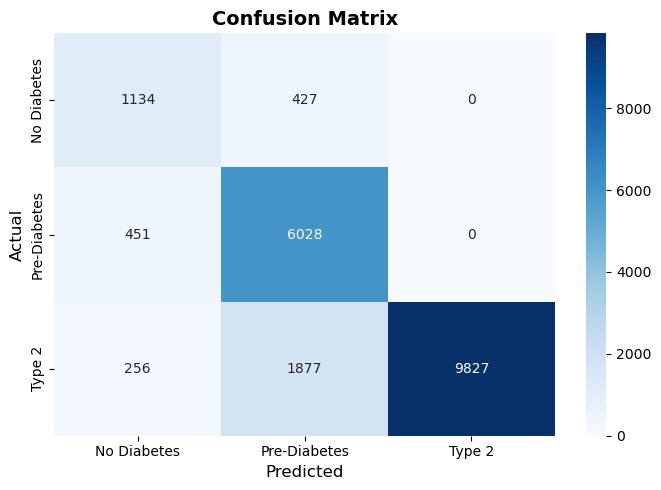


Epoch    17
Train_cost  = 0.3254 | Test_cost  = 0.3406 | Train_score = 0.8585 | Test_score = 0.8495 |
==> EarlyStop patience =  1 | Best test_score: 0.8629


─────────────────────────────────────────────────── 🚀 EPOCH 18 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1387.82it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3257 │ 0.3222 │ │ No Diabetes  │  0.9090  │
│ Accuracy │ 0.8584 │ 0.8582 │ │ Pre-Diabetes │  0.8643  │
│ Macro F1 │ 0.8014 │ 0.8050 │ │    Type 2    │  0.8483  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

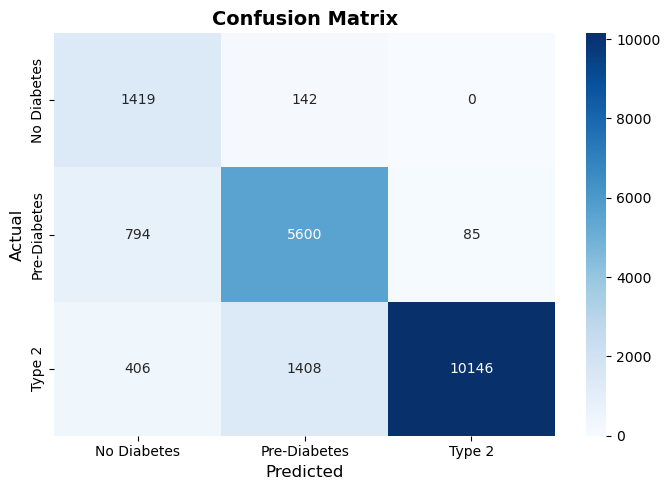


Epoch    18
Train_cost  = 0.3257 | Test_cost  = 0.3222 | Train_score = 0.8584 | Test_score = 0.8582 |
==> EarlyStop patience =  2 | Best test_score: 0.8629


─────────────────────────────────────────────────── 🚀 EPOCH 19 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1393.63it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3246 │ 0.3192 │ │ No Diabetes  │  0.7777  │
│ Accuracy │ 0.8593 │ 0.8612 │ │ Pre-Diabetes │  0.9051  │
│ Macro F1 │ 0.8032 │ 0.8041 │ │    Type 2    │  0.8484  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

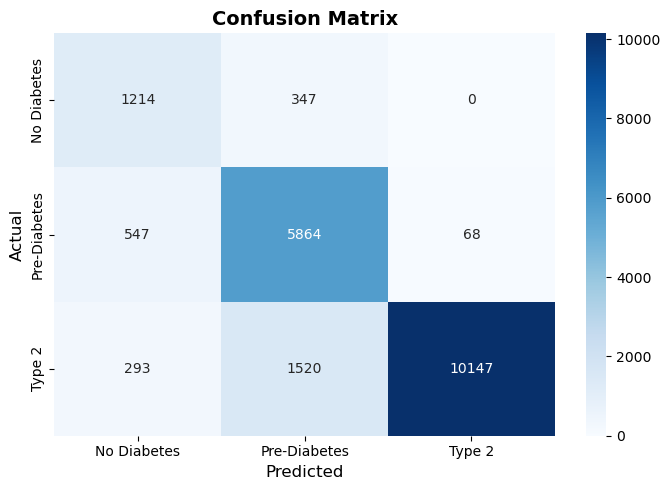


Epoch    19
Train_cost  = 0.3246 | Test_cost  = 0.3192 | Train_score = 0.8593 | Test_score = 0.8612 |
==> EarlyStop patience =  3 | Best test_score: 0.8629


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1467.94it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3251 │ 0.3194 │ │ No Diabetes  │  0.9058  │
│ Accuracy │ 0.8588 │ 0.8599 │ │ Pre-Diabetes │  0.8710  │
│ Macro F1 │ 0.8021 │ 0.8063 │ │    Type 2    │  0.8479  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

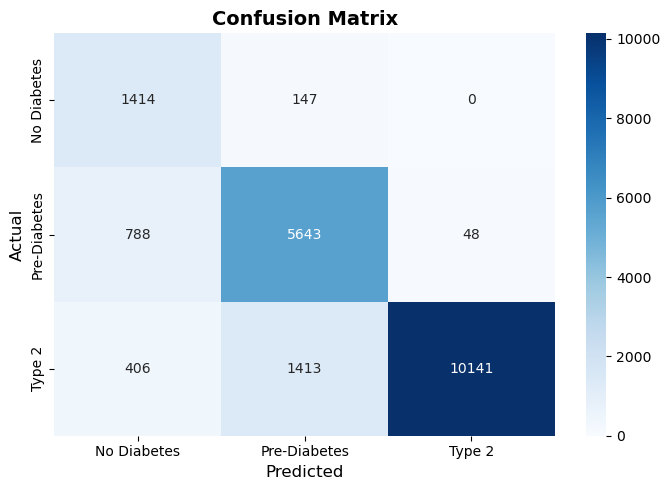


Epoch    20
Train_cost  = 0.3251 | Test_cost  = 0.3194 | Train_score = 0.8588 | Test_score = 0.8599 |


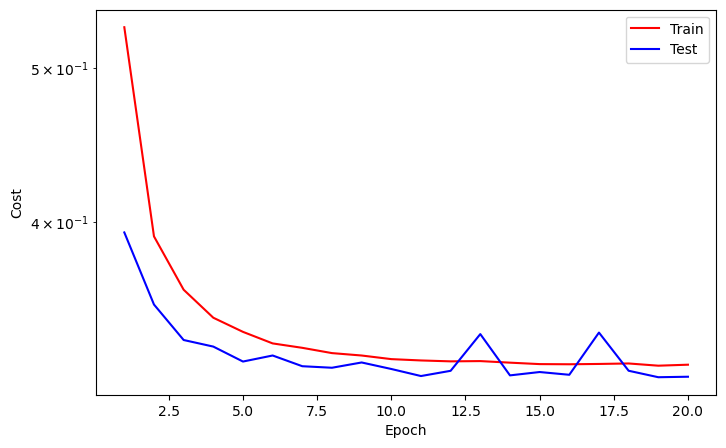

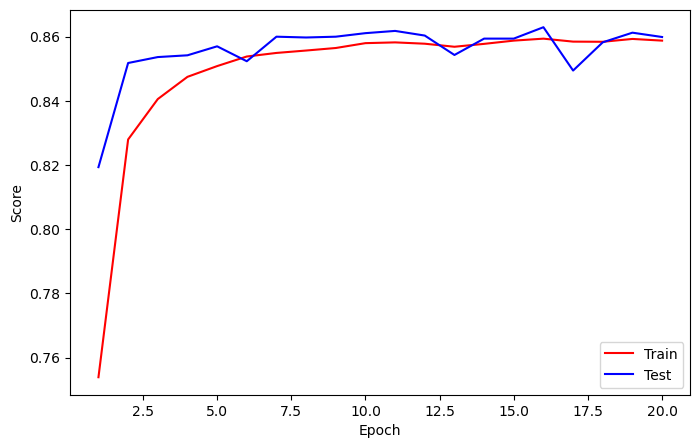

==> EarlyStop patience =  4 | Best test_score: 0.8629


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 625/625 [00:00<00:00, 1354.04it/s]


           Summary                 Per-Class Accuracy     
┏━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric   ┃  Train ┃   Test ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Loss     │ 0.3240 │ 0.3199 │ │ No Diabetes  │  0.7188  │
│ Accuracy │ 0.8585 │ 0.8623 │ │ Pre-Diabetes │  0.9239  │
│ Macro F1 │ 0.8012 │ 0.8019 │ │    Type 2    │  0.8477  │
└──────────┴────────┴────────┘ └──────────────┴──────────┘

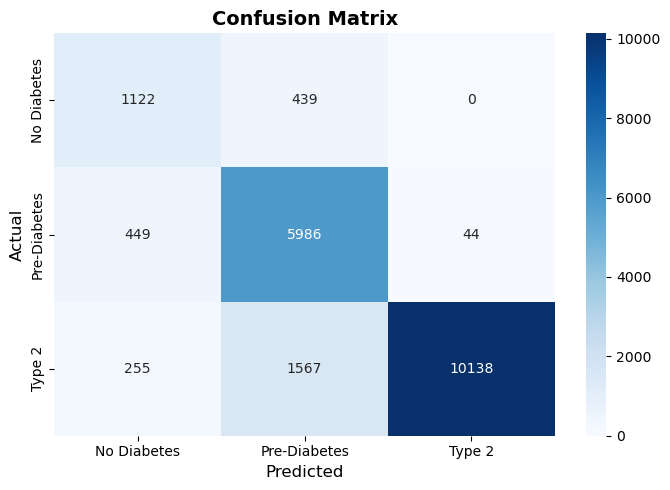


Epoch    21
Train_cost  = 0.3240 | Test_cost  = 0.3199 | Train_score = 0.8585 | Test_score = 0.8623 |
==> EarlyStop patience =  5 | Best test_score: 0.8629
==> Execute Early Stopping at epoch: 21 | Best test_score: 0.8629
==> Best model is saved at multi-class-clasification/two-d/diabetes_dataset/


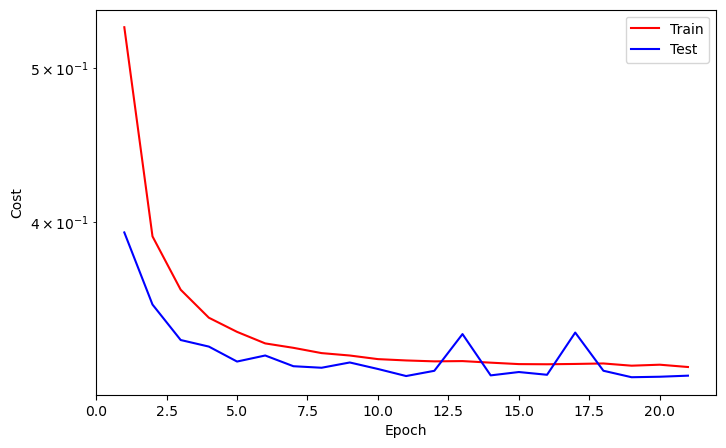

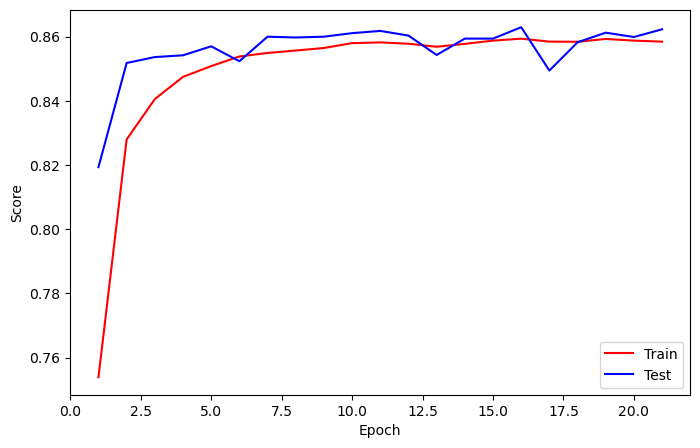

⏹️ Training dihentikan oleh early stopping.

In [87]:
from train_and_evaluate import train_and_evaluate_multi_class



train_and_evaluate_multi_class(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback,
    dimension='2d'
)

# Evaluate

      📊 Evaluasi Model           🎯 Per-Class Accuracy   
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metrik            ┃  Nilai ┃ ┃    Class     ┃ Accuracy ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ 💥 Loss (avg)     │ 0.3203 │ │ No Diabetes  │  0.8251  │
│ 🔹 Accuracy       │ 0.8629 │ │ Pre-Diabetes │  0.9035  │
│ 📈 Macro F1-score │ 0.8077 │ │    Type 2    │  0.8459  │
└───────────────────┴────────┘ └──────────────┴──────────┘

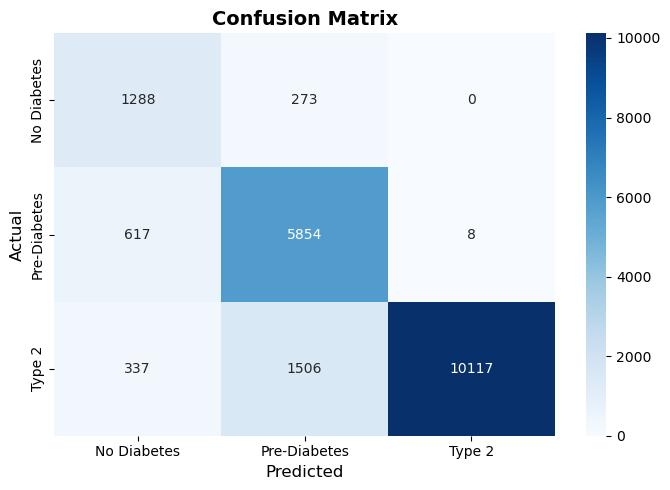

In [88]:
from evaluate import evaluate_multi_class
hsl = evaluate_multi_class(
    model=model,
    dataloader=test_loader,
    labels=labels,
    criterion=criterion,
    device=device,
    dimension='2d'
)

In [89]:
hsl['df'].head(200)

,Target,Prediksi,Prob (%),Benar (%),Benar
0,Type 2,Type 2,100.000000,100.000000,1
1,No Diabetes,No Diabetes,64.360001,64.360001,1
2,Pre-Diabetes,Pre-Diabetes,82.669998,82.669998,1
3,No Diabetes,No Diabetes,55.220001,55.220001,1
4,Pre-Diabetes,Pre-Diabetes,81.339996,81.339996,1
...,...,...,...,...,...
195,Pre-Diabetes,Pre-Diabetes,81.440002,81.440002,1
196,Pre-Diabetes,Pre-Diabetes,48.669998,48.669998,1
197,Type 2,Type 2,100.000000,100.000000,1
198,Type 2,Type 2,100.000000,100.000000,1


# Pengaplikasian

In [90]:
#!pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension

In [92]:
import torch, json
from torch import optim, nn
from class_lib import Model1DPure
import joblib
import pandas as pd


# Load Config
try:
    config = torch.load(root_folder + "configs.pth", map_location="cpu", weights_only=False)
except:
    config = torch.load(root_folder + "configs.pth", map_location="cpu")

#Load Weights
weights= torch.load(root_folder + "weights_best.pth", map_location="cpu")

#Load Label Mapping
with open(root_folder + "label_mappings.json", "r") as f:
    label_mapping = json.load(f)


model = Model2DPure(
    input_dim_1  = config.input_1_dim, 
    input_dim_2  = config.input_2_dim, 
    hidden_dims_1= config.hidden_1_dims,
    hidden_dims_2= config.hidden_2_dims,
    combined_dims= config.combine_dims,
    output_dim   = config.output_dim,
    dropout=config.dropout, 
    activation=config.activation
)
model.load_state_dict(weights)
model.eval() 

Model2DPure(
  (net1): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (net2): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (net_combined): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [93]:
from aplokator import MultiClassPredictor


predictor = MultiClassPredictor(
    model=model,
    config=config,
    label_mapping=label_mapping,
    scaler_folder=root_folder,
    dimension="2d"
)

HTML(value='\n        <style>\n        .minimal-container { background: #f8f9fa; padding: 12px; border-radius:…